# Noise budget, 09-11 → 09-13 steady hold: sensitivity, laser RIN, laser↔rotor correlation

One notebook, one data window, one set of constants, for three questions about the
44 h laser-driven steady hold (`LASER_OFFSET` = 1300, 5.8 mW at the chamber, rotor at
~0.749 Hz; `analysis/dataset_20260911_drive_spindown.md`, dataset 1):

1. **Sensitivity**: how steady is the rotor? Its frequency noise σ_f(T) → minimum
   detectable torque/force. Uses rotor data only.
2. **Laser RIN**: how steady is the pushing laser? Fractional power noise from the PD, with
   a dark baseline. Uses PD data only.
3. **Correlation**: does the laser's wander drive the rotor's wander, and by how much?
   k = (δf/f)/(δP/P) at DC. Uses both.

They combine in §4 into a **noise projection**: the laser's contribution to rotor frequency
noise, next to the measured noise and the thermal floor.

**No power calibration anywhere.** RIN and k are fractional, and the sensitivity uses only
I, τ and the measured σ_f. No PD→mW, counts→mW or torque-per-mW enters any number here.

**Supersedes the numbers in `sensitivity_20260911.ipynb`** (left unchanged as a record).
Differences: I = 1.88e-11 (was 1.7e-11), lever arm = wing centroid 1.38 mm (was tip 1.88 mm),
window 1–40 h (was 1–45 h; the PD starts sliding at 40.5 h and the frequency dips in 43–45 h).
§1 checks that it reproduces the September numbers exactly with September's settings.

## 0. Constants and data

| | value | source |
|---|---|---|
| I | 1.88e-11 kg·m² | calculated disk + sail (`CLAUDE.md`, "calculated, never measured"); SolidWorks gives 1.7e-11, so ~10% systematic |
| τ | 79.8 min | free decay, `spindown_20260913.ipynb`; viscous law over 0.22–0.79 Hz confirmed in `damping_law_comparison.ipynb` |
| lever arm | 1.38 mm | SAL-001 wing centroid (uniform full-wing coating, 0.88–1.88 mm); tip = 1.88 mm |
| T_bath, NSIG | 300 K, 5 | as in July/September |

In [1]:
import os, numpy as np, h5py, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import decimate, welch, csd, coherence, lfilter
from scipy.ndimage import uniform_filter1d

DATA = os.path.expanduser('~/Library/CloudStorage/Dropbox/Microspheres/TFINER/data')
GPS_A, GPS_B = 1473204000, 1473376497          # dataset 1: laser-driven hold
DARK_FILE = 'Y1_RDS-PD_IN1_DQ_1473375897_1473435502.h5'   # dataset 2: laser OFF from +600 s
DARK_SKIP_S = 700                               # s into dataset 2 (laser off at +600 s)
DIVISOR = 2                                     # rotation = LES line / 2 (confirmed 09-14)

I_TOTAL = 1.88e-11        # kg m^2
I_ALT   = 1.7e-11         # kg m^2, SolidWorks -- systematic only
TAU_S   = 79.8 * 60       # s
GAMMA   = 1 / TAU_S
R_EFF   = 1.38e-3         # m, wing centroid
R_TIP   = 1.88e-3         # m, wing tip
KB_J, T_BATH, NSIG = 1.380649e-23, 300.0, 5.0

WIN_H = (1, 40)           # analysis window, hours from file start

In [2]:
def load(path):
    """Segment-aware .h5 reader (as in sensitivity_20260911); checks for gaps."""
    with h5py.File(path, 'r') as f:
        y = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s = f['segments']
        g0, i0, L = s['gps_start'][:], s['index_start'][:], s['length'][:]
        t = np.empty(len(y))
        for a, b, c in zip(g0, i0, L):
            t[b:b + c] = a + np.arange(c) / fs
    gap = np.abs(np.diff(g0) - L[:-1] / fs).max() if len(g0) > 1 else 0
    print(f'{os.path.basename(path)}: {len(y)/fs/3600:.2f} h, {len(g0)} segments, max gap {gap:.3f} s')
    return y, t, fs

def to_1hz(y, t, fs):
    n = int(len(y) // fs * fs); k = int(fs)
    return y[:n].reshape(-1, k).mean(1), t[:n].reshape(-1, k).mean(1)

les, t_les, fs = load(f'{DATA}/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_{GPS_A}_{GPS_B}.h5')
pd_raw, t_pd, fs_pd = load(f'{DATA}/PD/Y1_RDS-PD_IN1_DQ_{GPS_A}_{GPS_B}.h5')
pd1, tpd1 = to_1hz(pd_raw, t_pd, fs_pd); del pd_raw, t_pd
dk_raw, t_dk, fs_dk = load(f'{DATA}/PD/{DARK_FILE}')
dk1, _ = to_1hz(dk_raw, t_dk, fs_dk); del dk_raw, t_dk
dark = dk1[DARK_SKIP_S:]
DARK_LEVEL = dark.mean()
print(f'dark PD: {DARK_LEVEL:.3f} counts (std {dark.std():.3f}) over {len(dark)/3600:.1f} h')

Y1_RDS-LES_YAW_IN1_DQ_1473204000_1473376497.h5: 47.92 h, 288 segments, max gap 0.000 s
Y1_RDS-PD_IN1_DQ_1473204000_1473376497.h5: 47.92 h, 288 segments, max gap 0.000 s
Y1_RDS-PD_IN1_DQ_1473375897_1473435502.h5: 16.56 h, 100 segments, max gap 0.000 s
dark PD: 1.794 counts (std 0.089) over 16.4 h


### 0.1 Check: is the PD seeing only the laser?

The PD is a pickoff before the chamber, and a PBS + quarter-wave plate isolator keeps light
reflected off the spinning rotor from coming back to it. The isolator is efficient but
not necessarily perfect, so some rotor-reflected light may still reach the PD. This cell
looks for it in the **raw 1024 Hz PD** (two 1 h stretches inside 1–40 h), at multiples of
the rotation frequency taken from the LES in the same stretch. The dark (laser-off) PD is
shown on the same scale. The y-axis is a density: a line's height isn't its size (multiply
by ~0.07 here); the table gives line amplitudes directly.

**Rotor light (dotted lines):** present. The strongest line is at 2× rotation (two wings),
up to ~2000× above the floor, but only **~0.1 ‰ of the PD signal**, so the isolator
suppresses the return well. These lines are coherent with both LES axes (0.88–1.00), so
they are rotor light. The amplitude differs between 10 h and 30 h (0.08 vs 0.12 ‰).

**A comb at 0.308 Hz and its multiples (▼), reported, not interpreted.** Observations:
- ~0.15 ‰ at the fundamental, comparable to the rotor lines; runs to at least 3.4 Hz.
- **Not a rotation harmonic:** 0.308/0.749 = 0.41.
- **Absent with the laser off.** This rules out the PD electronics but can't separate the
  laser from rotor-reflected light, since switching the laser off removes both.
- **Absent in both LES axes** (YAW and PIT at the noise floor) and not coherent with them,
  so it isn't visible as rotor motion. This doesn't exclude a rotor tilt: a specular
  reflection swings through twice the tilt angle, and could change the light returning
  through the isolator while barely moving the silhouette the LES tracks.
- **Steady for 39 h, then switches off at ~43.5–44.3 h** (timeline table), during the
  unexplained 43–45 h frequency dip, after the PD slide began at 40.5 h, and ~1 h
  *before* the 45.5 h rotation jump. It doesn't reappear at the new rotation frequency.
  (Where the comb is absent, the amplitude column is just the noise in that bin; peak/floor
  is the discriminator.)

Its origin is open (laser side or a rotor tilt mode are both possible). Two further lines
near 1.93 and 1.99 Hz are unassigned.

**Why none of this matters for this notebook's numbers:** everything downstream uses the PD
averaged over 150 s windows (§1.1) or slower. Lines at 0.3–3 Hz are reduced by ≳100× by that
averaging, leaving ≲10⁻³ ‰ against ~2 ‰ of slow PD wander (§1.1b). The one route in is a
*steady* reflected component that drifts slowly. It isn't measured directly, but for a
strongly modulated reflection it should be of order the line amplitude (a few tenths of a ‰),
still well below the 2 ‰ wander. That last step is an order-of-magnitude argument, not a
measurement.

         data |      line | freq (Hz) | peak/floor | amp (permil of hold PD)
   PD 10-11 h |  1x f_rot |    0.7483 |         27 |                   0.021
   PD 10-11 h |  2x f_rot |    1.4983 |        729 |                   0.078
   PD 10-11 h |  3x f_rot |    2.2467 |         10 |                   0.009
   PD 10-11 h |  4x f_rot |    2.9967 |        372 |                   0.059
   PD 10-11 h |   1x comb |    0.3083 |        866 |                   0.157
   PD 10-11 h |   2x comb |    0.6167 |        778 |                   0.124
   PD 10-11 h |   3x comb |    0.9267 |        257 |                   0.064
   PD 10-11 h |   4x comb |    1.2350 |         61 |                   0.030
  YAW 10-11 h |   1x comb |    0.3100 |          2 |            (not in LES)
  PIT 10-11 h |   1x comb |    0.3100 |          2 |            (not in LES)
   PD 30-31 h |  1x f_rot |    0.7483 |        164 |                   0.042
   PD 30-31 h |  2x f_rot |    1.4983 |       2204 |                   0.120

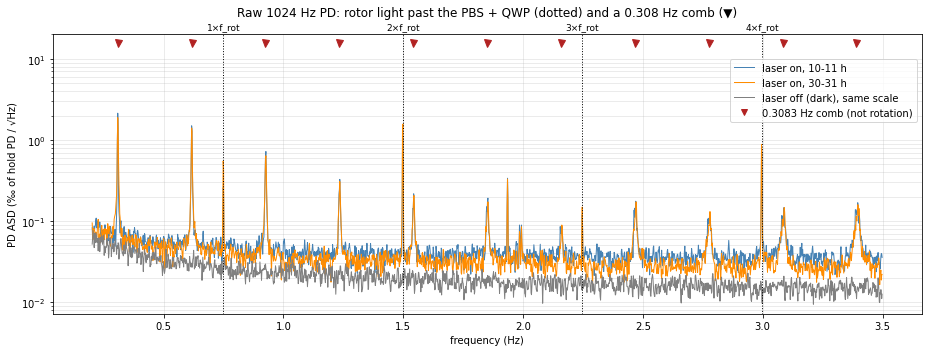


 hour | f_rot (Hz) | PD level | comb peak/floor | comb amp (permil)
  5.0 |     0.7492 |    470.6 |             620 |             0.145
 20.0 |     0.7492 |    470.4 |             881 |             0.161
 39.0 |     0.7492 |    472.0 |             665 |             0.151
 41.0 |     0.7492 |    439.5 |             180 |             0.108
 43.0 |     0.7483 |    407.2 |             408 |             0.120
 44.5 |     0.7483 |    404.9 |               2 |             0.036
 46.6 |     0.7883 |    390.0 |               3 |             0.062

 stretch | PD vs | coh @ 1x f_rot | coh @ 2x f_rot | coh @ comb
 10-11 h |   YAW |           0.88 |           0.99 |       0.04
 10-11 h |   PIT |           0.93 |           0.98 |       0.05
 30-31 h |   YAW |           0.99 |           1.00 |       0.29
 30-31 h |   PIT |           0.99 |           1.00 |       0.23
(~11 averages per stretch: coherence up to ~0.3 is consistent with noise)


In [3]:
LEAK_H = (10, 30)       # 1 h stretches, hours from file start (both inside 1-40 h)
N_HARM = 4              # harmonics to tabulate, of f_rot and of the 0.308 Hz comb

def raw_asd(path, h0, dur=3600, nps_s=600):
    """Welch PSD of a raw 1024 Hz stretch [h0, h0+dur) h from file start (no gaps, checked in load)."""
    with h5py.File(path, 'r') as f:
        fsr = float(f.attrs['sample_rate']); a = int(h0*3600*fsr)
        y = f['data'][a:a + int(dur*fsr)].astype(float)
    fw, P = welch(y - y.mean(), fsr, nperseg=int(nps_s*fsr))
    return fw, P, y.mean()

def line(fw, P, f0, lvl):
    """Strongest bin within +-10 mHz of f0: (freq, peak/local median, amplitude in permil of lvl)."""
    m = (fw > f0 - 0.01) & (fw < f0 + 0.01); j = np.flatnonzero(m)[np.argmax(P[m])]
    amp = np.sqrt(2*P[j-2:j+3].sum()*(fw[1] - fw[0]))       # sinusoid amplitude, +-2 bins
    return fw[j], P[j]/np.median(P[max(j-200, 0):j+200]), amp/lvl*1e3

PD_HOLD = f'{DATA}/PD/Y1_RDS-PD_IN1_DQ_{GPS_A}_{GPS_B}.h5'
LES_HOLD = f'{DATA}/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_{GPS_A}_{GPS_B}.h5'
PIT_HOLD = f'{DATA}/LES_pit/Y1_RDS-LES_PIT_IN1_DQ_{GPS_A}_{GPS_B}.h5'
F_COMB = 0.3083         # Hz, comb fundamental (Welch peak, 1.7 mHz bins; same at 10 h and 30 h)

fig, ax = plt.subplots(figsize=(13, 5))
print(f"{'data':>13} | {'line':>9} | {'freq (Hz)':>9} | {'peak/floor':>10} | {'amp (permil of hold PD)':>23}")
for h0, col in zip(LEAK_H, ('steelblue', 'darkorange')):
    fw, P, lvl = raw_asd(PD_HOLD, h0)
    lvl -= DARK_LEVEL
    fl, Pl, _ = raw_asd(LES_HOLD, h0)
    ml = (fl > 1.3) & (fl < 1.7); f_rot = fl[ml][np.argmax(Pl[ml])]/DIVISOR   # rotation from the LES line
    m = (fw > 0.2) & (fw < 3.5)
    ax.semilogy(fw[m], np.sqrt(P[m])/lvl*1e3, color=col, lw=1, label=f'laser on, {h0}-{h0+1} h')
    for name, f0 in [(f'{n}x f_rot', n*f_rot) for n in range(1, N_HARM+1)] + \
                    [(f'{n}x comb', n*F_COMB) for n in range(1, N_HARM+1)]:
        fj, pf, a = line(fw, P, f0, lvl)
        print(f'{"PD "+str(h0)+"-"+str(h0+1)+" h":>13} | {name:>9} | {fj:9.4f} | {pf:10.0f} | {a:23.3f}')
    for ch, (fq, Pq) in (('YAW', (fl, Pl)), ('PIT', raw_asd(PIT_HOLD, h0)[:2])):   # rotor motion, x and y
        fj, pf, _ = line(fq, Pq, F_COMB, 1)
        print(f'{ch+" "+str(h0)+"-"+str(h0+1)+" h":>13} | {"1x comb":>9} | {fj:9.4f} | {pf:10.0f} | {"(not in LES)" if pf < 10 else "PRESENT":>23}')

# laser off: same raw channel, 2-3 h into dataset 2, normalised to the HOLD PD level so it is directly comparable
fw, P, _ = raw_asd(f'{DATA}/PD/{DARK_FILE}', 2)
m = (fw > 0.2) & (fw < 3.5)
ax.semilogy(fw[m], np.sqrt(P[m])/lvl*1e3, color='gray', lw=1, label='laser off (dark), same scale')
for n in range(1, N_HARM+1):
    fj, pf, a = line(fw, P, n*F_COMB, lvl)
    print(f'{"dark":>13} | {f"{n}x comb":>9} | {fj:9.4f} | {pf:10.0f} | {a:23.3f}')

for n in range(1, N_HARM+1):
    ax.axvline(n*f_rot, color='k', ls=':', lw=1)
    ax.text(n*f_rot, 1.01, f'{n}×f_rot', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=9)
for n in range(1, int(3.5/F_COMB) + 1):   # the comb runs to the plot edge
    ax.plot(n*F_COMB, 0.97, 'v', color='firebrick', ms=7, transform=ax.get_xaxis_transform())
ax.plot([], [], 'v', color='firebrick', label=f'{F_COMB} Hz comb (not rotation)')
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('PD ASD (‰ of hold PD / √Hz)')
ax.set_title('Raw 1024 Hz PD: rotor light past the PBS + QWP (dotted) and a 0.308 Hz comb (▼)', pad=18)
ax.set_ylim(top=20); ax.legend(loc='upper right', bbox_to_anchor=(1, 0.93)); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

# when does the comb switch off? 30 min stretches; f_rot from the LES line
print(f"\n{'hour':>5} | {'f_rot (Hz)':>10} | {'PD level':>8} | {'comb peak/floor':>15} | {'comb amp (permil)':>17}")
for h0 in (5, 20, 39, 41, 43, 44.5, 46.6):
    fw, P, lvl = raw_asd(PD_HOLD, h0, dur=1800); lvl -= DARK_LEVEL
    fl, Pl, _ = raw_asd(LES_HOLD, h0, dur=1800)
    ml = (fl > 1.3) & (fl < 1.7); f_rot = fl[ml][np.argmax(Pl[ml])]/DIVISOR
    _, pf, a = line(fw, P, F_COMB, lvl)
    print(f'{h0:5.1f} | {f_rot:10.4f} | {lvl:8.1f} | {pf:15.0f} | {a:17.3f}')

# are the PD's rotor lines really rotor light? coherence with both LES axes (16 Hz is plenty below 3 Hz)
def raw16(path, h0, dur=3600):
    """Raw stretch decimated 1024 -> 16 Hz (FIR anti-alias)."""
    with h5py.File(path, 'r') as f:
        a = int(h0*3600*1024); y = f['data'][a:a + int(dur*1024)].astype(float)
    return decimate(decimate(y - y.mean(), 8, ftype='fir'), 8, ftype='fir')

print(f"\n{'stretch':>8} | {'PD vs':>5} | {'coh @ 1x f_rot':>14} | {'coh @ 2x f_rot':>14} | {'coh @ comb':>10}")
for h0 in LEAK_H:
    pd16, yaw16 = raw16(PD_HOLD, h0), raw16(LES_HOLD, h0)
    fq, Pq = welch(yaw16, fs=16, nperseg=16*600)
    mq = (fq > 1.3) & (fq < 1.7); f_rot = fq[mq][np.argmax(Pq[mq])]/DIVISOR
    for ch, sig in (('YAW', yaw16), ('PIT', raw16(PIT_HOLD, h0))):
        fc, C = coherence(pd16, sig, fs=16, nperseg=16*600)
        at = lambda f0: C[np.abs(fc - f0) < 0.003].max()
        print(f'{h0:3d}-{h0+1:<3d}h | {ch:>5} | {at(f_rot):14.2f} | {at(2*f_rot):14.2f} | {at(F_COMB):10.2f}')
print('(~11 averages per stretch: coherence up to ~0.3 is consistent with noise)')

## 1. Sensitivity

### 1.1 Frequency track

The band-following tracker from `sensitivity_20260911.ipynb`, unchanged: decimate to 16 Hz,
150 s windows every 60 s, FFT peak with parabolic interpolation, search band re-centred on
the last estimate. Rotation frequency = LES line / 2.

2873 estimates, FR 0.4125..0.7889 Hz, median SNR 622


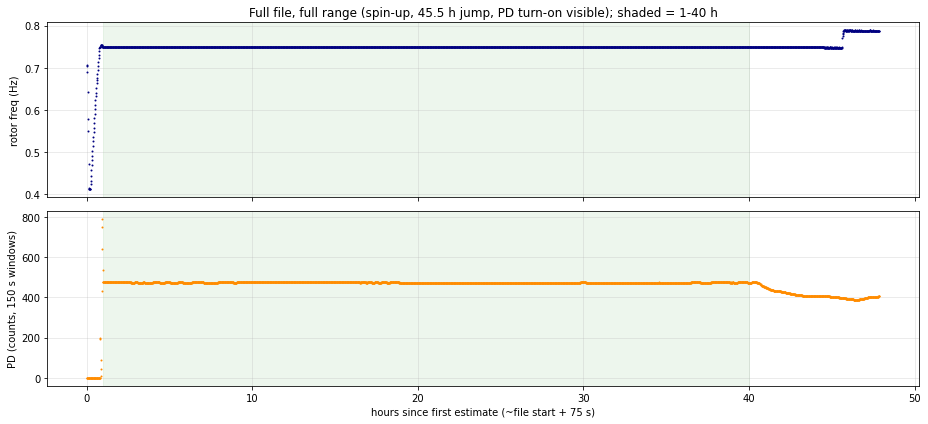

In [4]:
def peak_in_band(x, fsx, lo, hi):
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fpk, snr

y16 = decimate(decimate(les - les.mean(), 8, ftype='fir'), 8, ftype='fir')
fs16 = fs/64
t16 = t_les[0] + np.arange(len(y16))/fs16
T_FILE0 = t_les[0]; del les, t_les

WIN, STEP = 150.0, 60.0
nw, sw = int(WIN*fs16), int(STEP*fs16)
rows, track = [], 1.50
for i in range(0, len(y16)-nw, sw):
    tc = t16[i] + WIN/2
    fpk, snr = peak_in_band(y16[i:i+nw], fs16, max(track*0.85, 0.02), track*1.10)
    if np.isnan(fpk) or fpk <= 0: continue
    rows.append((tc, fpk/DIVISOR, snr))
    track = fpk
T, FR, SNR = map(np.array, zip(*rows))
T_REF = T[0]                  # hours are counted from the first tracker estimate (as in September)
H_ALL = (T - T_REF)/3600
print(f'{len(T)} estimates, FR {FR.min():.4f}..{FR.max():.4f} Hz, median SNR {np.median(SNR):.0f}')

# PD averaged over exactly the same 150 s windows -> one shared time grid for section 3
PDW = np.array([pd1[(tpd1 >= tc - WIN/2) & (tpd1 < tc + WIN/2)].mean() for tc in T])

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(H_ALL, FR, '.', ms=2, color='navy'); ax[0].set_ylabel('rotor freq (Hz)')
ax[1].plot(H_ALL, PDW, '.', ms=2, color='darkorange'); ax[1].set_ylabel('PD (counts, 150 s windows)')
for a in ax:
    a.axvspan(*WIN_H, color='green', alpha=0.07); a.grid(alpha=.3)
ax[1].set_xlabel('hours since first estimate (~file start + 75 s)')
ax[0].set_title(f'Full file, full range (spin-up, 45.5 h jump, PD turn-on visible); shaded = {WIN_H[0]}-{WIN_H[1]} h')
plt.tight_layout(); plt.show()

### 1.1b Frequency and PD on the same fractional scale

The two raw axes above aren't comparable: the frequency axis spans ~1% of its value and the
PD axis ~170%. Below, both are shown as **fractional deviation from their own 1–40 h mean**,
on one shared axis (parts per thousand, ‰). A 1 ‰ change in the PD and a 1 ‰ change in the
frequency are the same height.

- **Top:** matched scale, every 60 s point, whole file. The PD's slide after 40.5 h and the
  45.5 h frequency jump run off-scale; the first hour is spin-up / PD turn-on.
- **Bottom:** 1–40 h only, 30 min running mean of both, so slow wander (the timescale where a
  laser-driven effect would show up after the rotor's ~80 min response) is easier to compare.

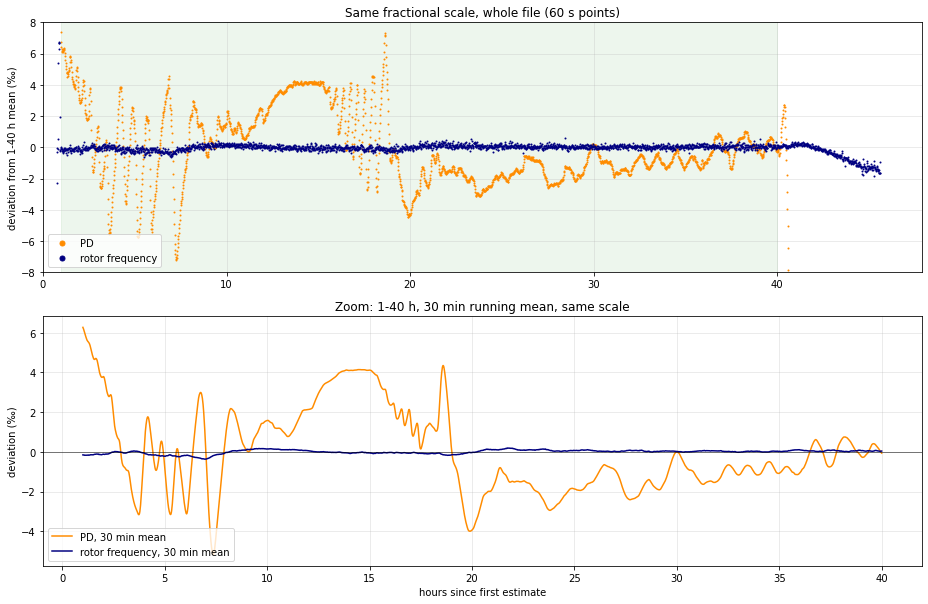

In [5]:
mref = (H_ALL >= WIN_H[0]) & (H_ALL <= WIN_H[1])
f_ref, p_ref = FR[mref].mean(), PDW[mref].mean() - DARK_LEVEL
dfr = (FR/f_ref - 1)*1e3                        # permil
dpd = ((PDW - DARK_LEVEL)/p_ref - 1)*1e3

fig, ax = plt.subplots(2, 1, figsize=(13, 8.5))
ax[0].plot(H_ALL, dpd, '.', ms=2, color='darkorange', label='PD')
ax[0].plot(H_ALL, dfr, '.', ms=2, color='navy', label='rotor frequency')
ax[0].axvspan(*WIN_H, color='green', alpha=0.07)
ax[0].set_ylim(-8, 8); ax[0].set_xlim(0, H_ALL.max())
ax[0].set_ylabel('deviation from 1-40 h mean (‰)')
ax[0].set_title('Same fractional scale, whole file (60 s points)')
ax[0].legend(loc='lower left', markerscale=5)

N30 = int(round(1800/np.median(np.diff(T))))
h_w = H_ALL[mref]
sm = lambda z: uniform_filter1d(z, N30, mode='nearest')
ax[1].plot(h_w, sm(dpd[mref]), color='darkorange', lw=1.5, label='PD, 30 min mean')
ax[1].plot(h_w, sm(dfr[mref]), color='navy', lw=1.5, label='rotor frequency, 30 min mean')
ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_ylabel('deviation (‰)'); ax[1].set_xlabel('hours since first estimate')
ax[1].set_title(f'Zoom: {WIN_H[0]}-{WIN_H[1]} h, 30 min running mean, same scale')
ax[1].legend(loc='lower left')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [6]:
print(f'1-40 h, 30 min means: PD std {sm(dpd[mref]).std():.2f} ‰, frequency std {sm(dfr[mref]).std():.3f} ‰ '
      f'(ratio {sm(dpd[mref]).std()/sm(dfr[mref]).std():.0f}x)')

1-40 h, 30 min means: PD std 2.12 ‰, frequency std 0.101 ‰ (ratio 21x)


### 1.2 Why 1–40 h, and the frequency in 2 h blocks

The PD starts a smooth ~15% slide at 40.5 h. During 43–45 h the rotor frequency dips
~0.7 mHz, and at ~45.5 h it jumps to ~0.788 Hz. None of that is understood (not
investigated here), and it isn't the stationary operating point, so the window stops at
40 h. The block table shows the frequency is steady throughout 1–41 h.

In [7]:
print(f"{'hours':>7} | {'mean f (Hz)':>11} | {'std (mHz)':>9} | {'mean PD':>8}")
for a in range(1, 47, 2):
    m = (H_ALL >= a) & (H_ALL < a+2)
    print(f'{a:3d}-{a+2:<3d} | {FR[m].mean():11.5f} | {FR[m].std()*1e3:9.3f} | {PDW[m].mean():8.1f}')

  hours | mean f (Hz) | std (mHz) |  mean PD
  1-3   |     0.74897 |     0.101 |    475.4
  3-5   |     0.74898 |     0.111 |    473.5
  5-7   |     0.74887 |     0.110 |    473.6
  7-9   |     0.74900 |     0.134 |    473.5
  9-11  |     0.74915 |     0.068 |    474.3
 11-13  |     0.74908 |     0.080 |    474.9
 13-15  |     0.74902 |     0.084 |    475.7
 15-17  |     0.74901 |     0.083 |    475.1
 17-19  |     0.74897 |     0.090 |    474.6
 19-21  |     0.74903 |     0.113 |    472.7
 21-23  |     0.74914 |     0.092 |    473.2
 23-25  |     0.74910 |     0.092 |    472.7
 25-27  |     0.74908 |     0.080 |    473.2
 27-29  |     0.74908 |     0.084 |    473.0
 29-31  |     0.74906 |     0.065 |    473.4
 31-33  |     0.74907 |     0.073 |    473.2
 33-35  |     0.74906 |     0.075 |    473.4
 35-37  |     0.74909 |     0.078 |    473.6
 37-39  |     0.74908 |     0.096 |    473.9
 39-41  |     0.74910 |     0.083 |    470.9
 41-43  |     0.74904 |     0.151 |    427.5
 43-45  | 

### 1.3 σ_f(T) and minimum detectable torque and force

Same method as `sensitivity_20260911.ipynb` §3–4. σ_f(T) is the std of T-long block means
of the linearly detrended frequency. The frequency-channel threshold is

$$\Delta\tau_{\min}(T) = \frac{2\pi I\,\gamma\,N_\sigma\,\sigma_f(T)}{1 - e^{-\gamma T}},\qquad
F_{\min} = \Delta\tau_{\min}/r$$

(force on one wing at lever arm r). The **first table is a regression check**: September's
settings (I = 1.7e-11, r = 1.88 mm, window 1–45 h) must reproduce its published numbers
(18.15 fN at 1 h, 6.96 fN at 4 h).

REGRESSION (Sept settings: I=1.7e-11, r=1.88 mm, 1-45 h)
   T=    60 s  F=  884.39 fN
   T=   300 s  F=  165.98 fN
   T=   600 s  F=   84.33 fN
   T=  1800 s  F=   31.18 fN
   T=  3600 s  F=   18.15 fN
   T=  7200 s  F=   11.51 fN
   T= 14400 s  F=    6.96 fN
   -> matches sensitivity_20260911 (18.15 fN @1 h, 6.96 fN @4 h)

THIS NOTEBOOK: I=1.88e-11, tau=79.8 min, window 1-40 h, resid std 0.1064 mHz
      T | sigma_f (Hz) | dtau_min (N m) | F @1.38 mm (fN) | F @1.88 mm (fN)
     60 |    1.064e-04 |      1.054e-15 |          763.56 |          560.48
    300 |    7.773e-05 |      1.579e-16 |          114.40 |           83.97
    600 |    7.210e-05 |      7.551e-17 |           54.72 |           40.17
   1800 |    6.645e-05 |      2.616e-17 |           18.96 |           13.91
   3600 |    6.287e-05 |      1.467e-17 |           10.63 |            7.80
   7200 |    5.445e-05 |      8.637e-18 |            6.26 |            4.59
  14400 |    4.919e-05 |      6.383e-18 |            4.63 |      

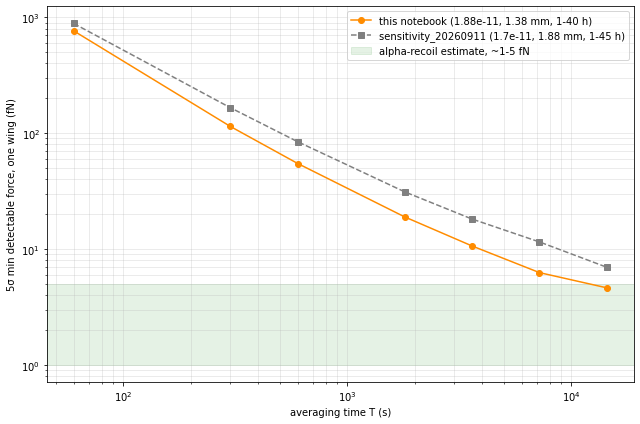

In [8]:
T_AVGS = np.array([60, 300, 600, 1800, 3600, 7200, 14400])

def window(h0, h1):
    m = (H_ALL >= h0) & (H_ALL <= h1)
    t = T[m] - T[m][0]
    return m, t

def sigma_f_table(h0, h1):
    m, t = window(h0, h1)
    r = FR[m] - np.polyval(np.polyfit(t, FR[m], 1), t)
    dt = np.median(np.diff(t)); out = []
    for Ta in T_AVGS:
        n = max(1, int(round(Ta/dt))); nb = len(r)//n
        out.append(r[:nb*n].reshape(nb, n).mean(1).std() if nb >= 4 else np.nan)
    return np.array(out), r, t

def min_torque(sf):
    return 2*np.pi*I_TOTAL*GAMMA*NSIG*sf / (1 - np.exp(-GAMMA*T_AVGS))

# --- regression check against sensitivity_20260911 ---
sf_sep, _, _ = sigma_f_table(1, 45)
F_sep = 2*np.pi*1.7e-11*GAMMA*NSIG*sf_sep/(1-np.exp(-GAMMA*T_AVGS)) / 1.88e-3
print('REGRESSION (Sept settings: I=1.7e-11, r=1.88 mm, 1-45 h)')
for Ta, F in zip(T_AVGS, F_sep): print(f'   T={Ta:6d} s  F={F*1e15:8.2f} fN')
assert abs(F_sep[4]*1e15 - 18.15) < 0.05 and abs(F_sep[6]*1e15 - 6.96) < 0.05, 'regression failed'
print('   -> matches sensitivity_20260911 (18.15 fN @1 h, 6.96 fN @4 h)\n')

# --- this notebook's numbers ---
sf, resid, t_res = sigma_f_table(*WIN_H)
dtau = min_torque(sf)
print(f'THIS NOTEBOOK: I={I_TOTAL:.2e}, tau={TAU_S/60:.1f} min, window {WIN_H[0]}-{WIN_H[1]} h, '
      f'resid std {resid.std()*1e3:.4f} mHz')
print(f"{'T':>7} | {'sigma_f (Hz)':>12} | {'dtau_min (N m)':>14} | {'F @1.38 mm (fN)':>15} | {'F @1.88 mm (fN)':>15}")
for Ta, s, d in zip(T_AVGS, sf, dtau):
    print(f'{Ta:>7d} | {s:12.3e} | {d:14.3e} | {d/R_EFF*1e15:15.2f} | {d/R_TIP*1e15:15.2f}')
print(f'\nI systematic: with I = {I_ALT:.1e} every torque/force number is x{I_ALT/I_TOTAL:.3f}.')

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(T_AVGS, dtau/R_EFF*1e15, 'o-', color='darkorange', label='this notebook (1.88e-11, 1.38 mm, 1-40 h)')
ax.loglog(T_AVGS, F_sep*1e15, 's--', color='gray', label='sensitivity_20260911 (1.7e-11, 1.88 mm, 1-45 h)')
ax.axhspan(1, 5, color='green', alpha=0.1, label='alpha-recoil estimate, ~1-5 fN')
ax.set_xlabel('averaging time T (s)'); ax.set_ylabel(f'{NSIG:.0f}σ min detectable force, one wing (fN)')
ax.legend(); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

### 1.4 Frequency noise vs the thermal floor

$S_\Omega(f) = 4k_BT\gamma / [I(\gamma^2 + (2\pi f)^2)]$, ASD in Hz/√Hz = √S_Ω / 2π.
Welch at the tracker's native 60 s cadence (Nyquist 8.3 mHz), as in September §5.

In [9]:
def thermal_asd_f(f):
    return np.sqrt(4*KB_J*T_BATH*GAMMA/(I_TOTAL*(GAMMA**2 + (2*np.pi*f)**2)))/(2*np.pi)

dt_tr = np.median(np.diff(t_res)); fs_tr = 1/dt_tr
NPS = 256
f_tr, P_f = welch(resid, fs=fs_tr, nperseg=NPS)
asd_f = np.sqrt(P_f)
print(f"{'freq':>10} | {'measured':>10} | {'thermal':>10} | x thermal")
for fr in (1.3e-4, 1e-3, 5e-3):
    j = np.argmin(abs(f_tr - fr))
    print(f'{f_tr[j]*1e3:8.3f}mHz | {asd_f[j]:10.3e} | {thermal_asd_f(f_tr[j]):10.3e} | {asd_f[j]/thermal_asd_f(f_tr[j]):6.0f}x')

      freq |   measured |    thermal | x thermal
   0.130mHz |  2.385e-03 |  8.087e-05 |     29x
   0.977mHz |  1.095e-03 |  1.112e-05 |     98x
   5.013mHz |  8.230e-04 |  2.168e-06 |    380x


## 2. Laser RIN (fractional)

Relative intensity noise of the pushing laser as the PD sees it: PD counts minus the dark
level, divided by the mean. Same low-frequency method as `laser_dark_vs_on.ipynb`: 1 Hz
series, one global linear detrend, Welch with 10 000 s segments (0.1 mHz resolution,
trusted above ~0.3 mHz). The **dark baseline** is the same PD with the laser off, from the
spindown that immediately follows the hold (dataset 2, +700 s onward), so the alignment
and electronics are unchanged. It's expressed as RIN at the same operating level.

ON level 473.84 counts, dark 1.794 -> signal 472.04 counts; 39.0 h
averages: ON ~27, DARK ~11

      band (mHz) | RIN ON (/rtHz) | DARK (/rtHz) | ON/DARK
   0.30-    1.0 |       3.39e-02 |     1.50e-03 |   22.6x
   1.00-    3.0 |       2.45e-03 |     7.91e-04 |    3.1x
   3.00-   10.0 |       7.46e-04 |     5.77e-04 |    1.3x
  10.00-  100.0 |       2.30e-04 |     1.53e-04 |    1.5x
 100.00-  500.0 |       7.38e-05 |     4.18e-05 |    1.8x


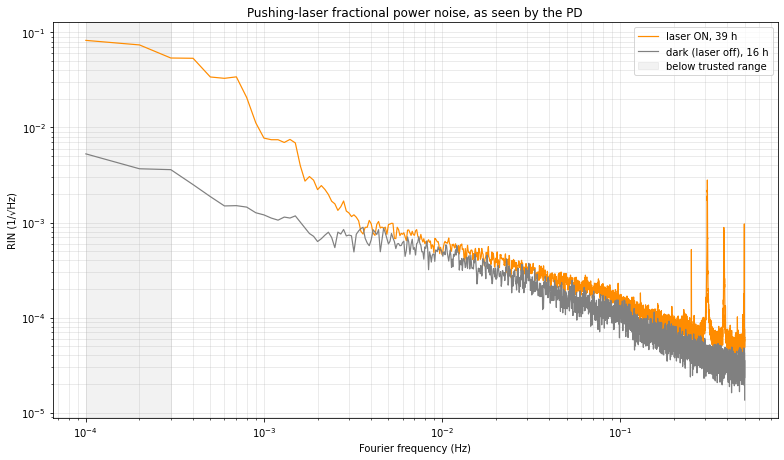

In [10]:
m1 = (tpd1 - T_REF >= WIN_H[0]*3600) & (tpd1 - T_REF < WIN_H[1]*3600)
on = pd1[m1].astype(float)
P0 = on.mean() - DARK_LEVEL
print(f'ON level {on.mean():.2f} counts, dark {DARK_LEVEL:.3f} -> signal {P0:.2f} counts; {len(on)/3600:.1f} h')

SEG_LO_S = 10000
def asd_lowf(y, fs=1.0, seg_s=SEG_LO_S):
    ts = np.arange(len(y))/fs
    yd = y - np.polyval(np.polyfit(ts, y, 1), ts)
    f, P = welch(yd, fs=fs, nperseg=int(seg_s*fs))
    return f, np.sqrt(P), len(y)/(seg_s*fs/2) - 1

f_r, a_on, n_on = asd_lowf(on)
_, a_dk, n_dk = asd_lowf(dark)
rin_on, rin_dk = a_on/P0, a_dk/P0
print(f'averages: ON ~{n_on:.0f}, DARK ~{n_dk:.0f}\n')

BANDS = [(3e-4,1e-3),(1e-3,3e-3),(3e-3,1e-2),(1e-2,1e-1),(0.1,0.5)]
print(f"{'band (mHz)':>16} | {'RIN ON (/rtHz)':>14} | {'DARK (/rtHz)':>12} | ON/DARK")
for lo, hi in BANDS:
    b = (f_r > lo) & (f_r < hi)
    r1, r2 = np.median(rin_on[b]), np.median(rin_dk[b])
    print(f'{lo*1e3:7.2f}-{hi*1e3:7.1f} | {r1:14.2e} | {r2:12.2e} | {r1/r2:6.1f}x')

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.loglog(f_r[1:], rin_on[1:], color='darkorange', lw=1.2, label=f'laser ON, {len(on)/3600:.0f} h')
ax.loglog(f_r[1:], rin_dk[1:], color='gray', lw=1.2, label=f'dark (laser off), {len(dark)/3600:.0f} h')
ax.axvspan(1e-4, 3e-4, color='gray', alpha=0.1, label='below trusted range')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('RIN (1/√Hz)')
ax.set_title('Pushing-laser fractional power noise, as seen by the PD')
ax.legend(); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

### 2.0b Requirement: three candidates (for comparison, not yet adopted)

All three use the PI's logic from `laser_dark_vs_on.ipynb`: laser power noise enters as torque
through the same mechanical response as the thermal torque, so the requirement is
"laser torque noise = thermal torque noise", independent of Fourier frequency:
RIN_req = √(4k_BTγI) / (torque per mW × P). They differ only in the **torque per mW**:

- **(A) steady-state ratio, no calibration.** If the laser is what holds the rotor at f₀, its torque
  equals the drag torque Iγ·2πf₀, so torque per mW = Iγ·2πf₀ / P and RIN_req = √(4k_BTγI) / (Iγ·2πf₀).
  Uses only I, τ and f₀. Assumes k = 1 (torque ∝ PD power, laser supplies all the steady torque).
- **(B) the PI's number**, 0.735 µW/√Hz at the chamber, converted to RIN at this run's 5.8 mW.
  Uses κ_PD = 7.35e-16 N·m/count and 16.2 counts/mW from the July step-down, with τ = 67.65 min.
  `apparatus_log.md` lists that `REQ_UW` as valid "≤ 07-27 only" and κ_PD as "step-down gain
  only". It implies a laser torque 3.7× the drag torque that holds the rotor here.
- **(C) the slope measured in the 09-15 step-down, 1030 → 1010 counts** (§5): the only pair that is
  clean, plateaued and large (Δf_ss ≈ 21 mHz). Drawn as a **band** because ΔP isn't measured: the
  strict edge uses commanded counts (11.87 µW/count), the lax edge the step-down PD (which that
  notebook flags as suspect). **Provisional** until power-meter readings at 1030/1010 replace ΔP.
  It is the local slope at 1030–1010, not at 1300, where the step-down shows almost no response.

The 5.8 mW used to express (B) and (C) as RIN is itself a power calibration; (A) as a RIN doesn't
need it. §3 measures |k| < 0.033 for the PD's wander, so every line answers "*if* the PD wander
reached the sail as torque, would it matter?" §4 is the measured-k version.

thermal torque ASD 8.066e-18 N m/rtHz (tau = 79.8 min); drag torque at f0 = 0.74905 Hz: 1.848e-14 N m
(C): df_ss = 21.05 mHz over dP = 237 uW (commanded) / 395 uW (PD)

                         candidate | torque/mW (N m) | req (uW/rtHz) | RIN req (/rtHz)
     (A) steady-state ratio, k = 1 |        3.19e-15 |          2.53 |        4.36e-04
                (B) PI, July kappa |        1.19e-14 |          0.68 |        1.17e-04
 (C) step 1030->1010, commanded dP |        2.19e-15 |          3.69 |        6.36e-04
        (C) step 1030->1010, PD dP |        1.32e-15 |          6.13 |        1.06e-03

(B) implies a laser torque at 5.8 mW of 6.91e-14 N m = 3.7x the drag torque

      band (mHz) |    RIN ON | x req (A) | x req (B) |    x req (C)
   0.30-    1.0 |  3.39e-02 |     77.7x |    290.6x |  32.1-53.4x
   1.00-    3.0 |  2.45e-03 |      5.6x |     20.9x |   2.3- 3.8x
   3.00-   10.0 |  7.46e-04 |      1.7x |      6.4x |   0.7- 1.2x
  10.00-  100.0 |  2.30e-04 |      0.5x |      2.0x 

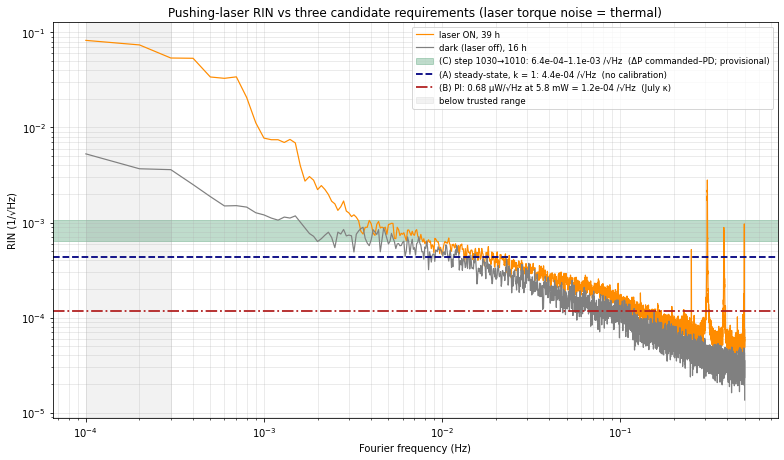

In [11]:
# Three candidate requirements on the same RIN plot (see markdown above) -- for choosing, not yet adopted
mR, _ = window(*WIN_H)
f0_hold = FR[mR].mean()
S_N_TH = np.sqrt(4*KB_J*T_BATH*GAMMA*I_TOTAL)       # thermal torque ASD, N m/rtHz
N_HOLD = I_TOTAL*GAMMA*2*np.pi*f0_hold              # drag torque at f0 = the laser torque, if the laser holds the rotor
P_CHAMBER_MW = 5.8                                  # LASER_OFFSET 1300 (dataset notes) -- itself a power calibration

# (A) calibration-free: torque per mW = steady-state ratio N_HOLD / P (k = 1)
TPM_A = N_HOLD/P_CHAMBER_MW
# (B) PI / laser_dark_vs_on: kappa_PD 7.35e-16 N m/count x 16.2 cts/mW (July step-down, tau 67.65 min -> 0.735 uW/rtHz)
TPM_B = 7.3499e-16*167.6/10.34
# (C) slope from the 09-15 step-down, 1030 -> 1010 (the only clean, large, plateaued pair; §5 table)
st = pd.read_csv('stepdown_20260914_steps.csv').drop_duplicates('offset').set_index('offset')
df_step = st.loc[1030, 'f_ss'] - st.loc[1010, 'f_ss']
dP_cmd = 20*11.87e-3                                # mW: commanded counts x 11.87 uW/count (apparatus_log, "still good")
dP_pd = (360.62 - 329.09)/463.23*P_CHAMBER_MW       # mW: step-down PD means (stepdown_20260914 §4); 463 cts at 1300
TPM_C = np.array([I_TOTAL*GAMMA*2*np.pi*df_step/dP for dP in (dP_cmd, dP_pd)])   # N m/mW, [commanded, PD]

rin_req = lambda tpm: S_N_TH/tpm/P_CHAMBER_MW       # laser torque noise = thermal  ->  RIN at this run's power
RIN_REQ_SS, RIN_REQ_PI, RIN_REQ_C = rin_req(TPM_A), rin_req(TPM_B), rin_req(TPM_C)

print(f'thermal torque ASD {S_N_TH:.3e} N m/rtHz (tau = {TAU_S/60:.1f} min); drag torque at f0 = {f0_hold:.5f} Hz: {N_HOLD:.3e} N m')
print(f'(C): df_ss = {df_step*1e3:.2f} mHz over dP = {dP_cmd*1e3:.0f} uW (commanded) / {dP_pd*1e3:.0f} uW (PD)\n')
print(f"{'candidate':>34} | {'torque/mW (N m)':>15} | {'req (uW/rtHz)':>13} | {'RIN req (/rtHz)':>15}")
for name, tpm in [('(A) steady-state ratio, k = 1', TPM_A), ('(B) PI, July kappa', TPM_B),
                  ('(C) step 1030->1010, commanded dP', TPM_C[0]), ('(C) step 1030->1010, PD dP', TPM_C[1])]:
    print(f'{name:>34} | {tpm:15.2e} | {S_N_TH/tpm*1e3:13.2f} | {rin_req(tpm):15.2e}')
print(f'\n(B) implies a laser torque at {P_CHAMBER_MW} mW of {TPM_B*P_CHAMBER_MW:.2e} N m = {TPM_B*P_CHAMBER_MW/N_HOLD:.1f}x the drag torque\n')

def crossing(req, nsm=9):
    """Lowest trusted frequency where the (running-median) ON RIN falls below req."""
    sm = np.array([np.median(rin_on[max(i-nsm//2, 0):i+nsm//2+1]) for i in range(len(rin_on))])
    ok = (f_r > 3e-4) & (sm < req)
    return f_r[ok][0] if ok.any() else np.nan

print(f"{'band (mHz)':>16} | {'RIN ON':>9} | {'x req (A)':>9} | {'x req (B)':>9} | {'x req (C)':>12}")
for lo, hi in BANDS:
    b = (f_r > lo) & (f_r < hi); r1 = np.median(rin_on[b])
    print(f'{lo*1e3:7.2f}-{hi*1e3:7.1f} | {r1:9.2e} | {r1/RIN_REQ_SS:8.1f}x | {r1/RIN_REQ_PI:8.1f}x | '
          f'{r1/RIN_REQ_C[1]:5.1f}-{r1/RIN_REQ_C[0]:4.1f}x')
print(f'\nON RIN falls below (A) above ~{crossing(RIN_REQ_SS)*1e3:.1f} mHz, (B) above ~{crossing(RIN_REQ_PI)*1e3:.1f} mHz, '
      f'(C, strict edge) above ~{crossing(RIN_REQ_C[0])*1e3:.1f} mHz')

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.loglog(f_r[1:], rin_on[1:], color='darkorange', lw=1.2, label=f'laser ON, {len(on)/3600:.0f} h')
ax.loglog(f_r[1:], rin_dk[1:], color='gray', lw=1.2, label=f'dark (laser off), {len(dark)/3600:.0f} h')
ax.axhspan(*RIN_REQ_C, color='seagreen', alpha=0.3,
           label=f'(C) step 1030→1010: {RIN_REQ_C[0]:.1e}–{RIN_REQ_C[1]:.1e} /√Hz  (ΔP commanded–PD; provisional)')
ax.axhline(RIN_REQ_SS, color='navy', ls='--', lw=1.8,
           label=f'(A) steady-state, k = 1: {RIN_REQ_SS:.1e} /√Hz  (no calibration)')
ax.axhline(RIN_REQ_PI, color='firebrick', ls='-.', lw=1.8,
           label=f'(B) PI: {S_N_TH/TPM_B*1e3:.2f} µW/√Hz at {P_CHAMBER_MW} mW = {RIN_REQ_PI:.1e} /√Hz  (July κ)')
ax.axvspan(1e-4, 3e-4, color='gray', alpha=0.1, label='below trusted range')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('RIN (1/√Hz)')
ax.set_title('Pushing-laser RIN vs three candidate requirements (laser torque noise = thermal)')
ax.legend(fontsize=8.5); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

### 2.1 Does the power wander average down?

Boxcar-smoothed, detrended fractional std vs the white-noise prediction (as in
`laser_dark_vs_on.ipynb` §6). Ratio ≫ 1 means correlated wander that doesn't average away.

In [12]:
print(f"{'boxcar':>7} | {'fractional std':>14} | {'white pred.':>11} | ratio")
for mins in [1, 5, 10, 30, 60, 120, 240]:
    n = mins*60
    sm = uniform_filter1d(on, n)[n//2:-n//2]
    ts = np.arange(len(sm)); sm = sm - np.polyval(np.polyfit(ts, sm, 1), ts)
    meas, pred = sm.std()/P0, on.std()/P0/np.sqrt(n)
    print(f'{mins:5d} m | {meas:14.2e} | {pred:11.2e} | {meas/pred:5.0f}x')
print(f'\nfor comparison, rotor fractional frequency std at 1 h: {sf[4]/FR[window(*WIN_H)[0]].mean():.2e}')

 boxcar | fractional std | white pred. | ratio
    1 m |       2.23e-03 |    3.06e-04 |     7x
    5 m |       2.21e-03 |    1.37e-04 |    16x
   10 m |       2.16e-03 |    9.69e-05 |    22x
   30 m |       1.94e-03 |    5.59e-05 |    35x
   60 m |       1.77e-03 |    3.95e-05 |    45x
  120 m |       1.59e-03 |    2.80e-05 |    57x
  240 m |       1.46e-03 |    1.98e-05 |    74x

for comparison, rotor fractional frequency std at 1 h: 8.39e-05


## 3. Correlation: does the PD wander show up in the rotor frequency?

**Model.** If rotor torque follows laser power, a fractional power change δP/P reaches the
fractional frequency through the rotor's first-order response:

$$\frac{\delta f}{f}(\omega) = k\,\frac{1}{1 + i\omega\tau}\,\frac{\delta P}{P}(\omega)$$

k is the DC gain. The simple picture (torque ∝ power, linear drag, no other torques) has k = 1.

**Both series are on the same grid**: the PD is averaged over exactly the tracker's 150 s
windows (§1.1), so both carry the same smoothing. Both are linearly detrended over 1–40 h.

**Estimator (changed from the plan; see §3.2).** k comes from a time-domain matched fit:
pass the measured δP/P through the model response (k = 1) to get the predicted δf/f,
then least-squares scale it onto the measured δf/f. The null distribution comes from
circularly shifting the PD by ≥ 4 h, which breaks any real link but keeps both series'
own colour. An injection test checks that the estimator recovers a known k.

In [13]:
mW, tW = window(*WIN_H)
def det(z): return z - np.polyval(np.polyfit(tW, z, 1), tW)
x = det((PDW[mW] - DARK_LEVEL)/P0)            # fractional power
y = det(FR[mW]/FR[mW].mean())                 # fractional frequency
dtW = np.median(np.diff(tW))

def response(xx, tau_s=TAU_S):
    a = dtW/tau_s
    return lfilter([a], [1, -(1-a)], xx)

def k_matched(xx, yy, tau_s=TAU_S):
    u = det(response(xx, tau_s))
    return np.dot(u, yy)/np.dot(u, u)

rng = np.random.default_rng(1)
SHIFTS = rng.integers(240, len(x) - 240, 2000)          # >= 4 h at 60 s cadence
k0 = k_matched(x, y)
null = np.array([k_matched(np.roll(x, s), y) for s in SHIFTS])
lo95, hi95 = np.percentile(null - null.mean(), [2.5, 97.5])
K_UL = max(abs(k0 - null.mean() + lo95), abs(k0 - null.mean() + hi95))
print(f'k (tau = {TAU_S/60:.1f} min) = {k0:+.4f} ± {null.std():.4f}   '
      f'({(k0-null.mean())/null.std():+.1f} σ from the shift-null)')
print(f'95% interval for k: [{k0-null.mean()+lo95:+.4f}, {k0-null.mean()+hi95:+.4f}]  ->  |k| < {K_UL:.3f}')

print('\ninjection test (y + k_true * model response to the measured PD):')
for kt in [0.01, 0.03, 0.1, 0.3, 1.0]:
    k_rec = k_matched(x, y + det(kt*response(x)))
    print(f'   k_true = {kt:5.2f} -> recovered {k_rec:+.4f}   (expected {k0+kt:+.4f})')

print('\nrobustness to the assumed response time:')
for tm in [5, 20, 44, 79.8, 160]:
    kk = k_matched(x, y, tm*60)
    nn = np.array([k_matched(np.roll(x, s), y, tm*60) for s in SHIFTS[:500]])
    print(f'   tau = {tm:5.1f} min: k = {kk:+.4f} ± {nn.std():.4f}')

print(f'\nfor scale: measured δf/f std {y.std():.2e}; predicted std if k = 1: {det(response(x)).std():.2e}')

k (tau = 79.8 min) = -0.0105 ± 0.0143   (-0.9 σ from the shift-null)
95% interval for k: [-0.0326, +0.0149]  ->  |k| < 0.033

injection test (y + k_true * model response to the measured PD):
   k_true =  0.01 -> recovered -0.0005   (expected -0.0005)
   k_true =  0.03 -> recovered +0.0195   (expected +0.0195)
   k_true =  0.10 -> recovered +0.0895   (expected +0.0895)
   k_true =  0.30 -> recovered +0.2895   (expected +0.2895)
   k_true =  1.00 -> recovered +0.9895   (expected +0.9895)

robustness to the assumed response time:
   tau =   5.0 min: k = -0.0070 ± 0.0083
   tau =  20.0 min: k = -0.0071 ± 0.0109
   tau =  44.0 min: k = -0.0077 ± 0.0128
   tau =  79.8 min: k = -0.0105 ± 0.0144
   tau = 160.0 min: k = -0.0171 ± 0.0177

for scale: measured δf/f std 1.42e-04; predicted std if k = 1: 1.46e-03


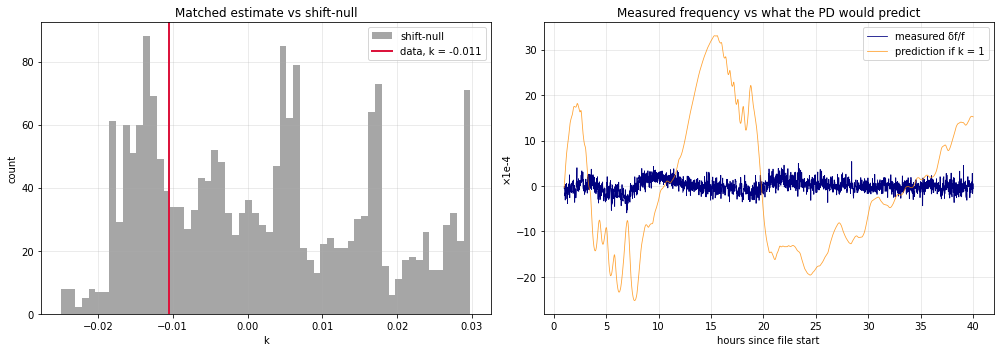

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(null, bins=60, color='gray', alpha=0.7, label='shift-null')
ax[0].axvline(k0, color='crimson', lw=2, label=f'data, k = {k0:+.3f}')
ax[0].set_xlabel('k'); ax[0].set_ylabel('count'); ax[0].legend(); ax[0].set_title('Matched estimate vs shift-null')
hh = tW/3600 + WIN_H[0]
ax[1].plot(hh, y*1e4, lw=0.8, color='navy', label='measured δf/f')
ax[1].plot(hh, det(response(x))*1e4, lw=0.8, color='darkorange', alpha=0.8, label='prediction if k = 1')
ax[1].set_xlabel('hours since file start'); ax[1].set_ylabel('×1e-4'); ax[1].legend()
ax[1].set_title('Measured frequency vs what the PD would predict')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 3.2 Coherence (diagnostic only)

The plan was coherence + transfer function over 0.1–5 mHz. The injection test showed that
estimator can't recover a known k in this band. The reason: the whole band sits above the
rotor corner (γ/2π ≈ 33 µHz), where any laser-driven signal is suppressed by 1/(2πfτ), so
it's buried under the rotor's own noise. It's shown for completeness, not used for k.

9 independent segments -> 95% null coherence ~ 0.31; median in 0.1-5 mHz = 0.05; bins above null: 8 of 75


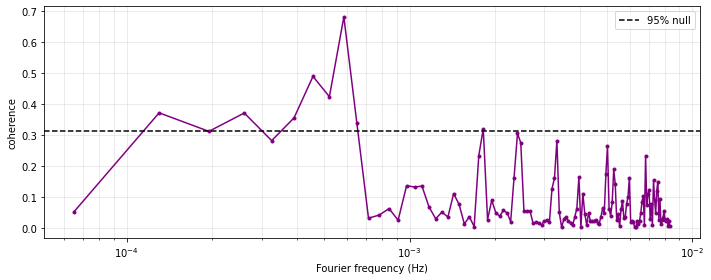

In [15]:
f_c, C = coherence(x, y, fs=1/dtW, nperseg=NPS)
n_ind = len(x)//NPS
C95 = 1 - 0.05**(1/(n_ind - 1))
band = (f_c >= 1e-4) & (f_c <= 5e-3)
print(f'{n_ind} independent segments -> 95% null coherence ~ {C95:.2f}; '
      f'median in 0.1-5 mHz = {np.median(C[band]):.2f}; bins above null: {(C[band] > C95).sum()} of {band.sum()}')
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(f_c[1:], C[1:], '.-', color='purple'); ax.axhline(C95, color='k', ls='--', label='95% null')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('coherence'); ax.legend(); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

## 4. Noise projection

All three in rotor-frequency units (Hz/√Hz), on the tracker's 60 s grid:
- **measured**: frequency noise from §1.4
- **laser, projected at the 95% upper limit on k**: |K_UL| · |1/(1+i2πfτ)| · RIN(f) · f₀,
  with RIN taken from the same window-averaged PD series x (so it carries the same smoothing)
- **thermal**: fluctuation-dissipation floor

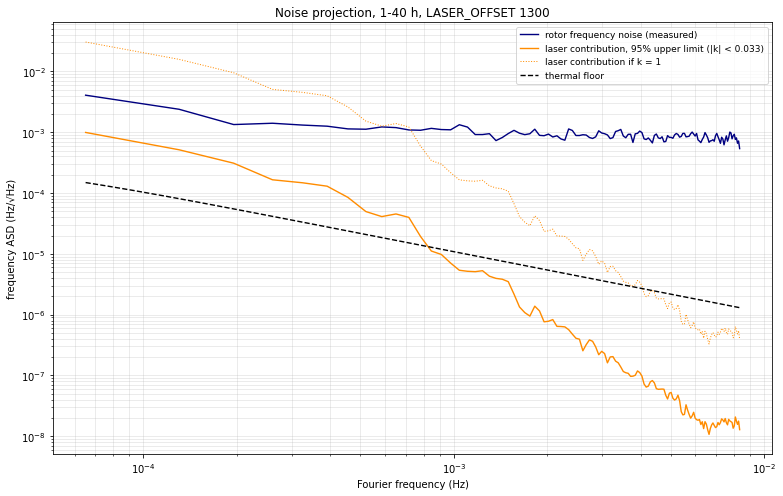

      freq |   measured | laser (UL) | laser if k=1 |    thermal
   0.130mHz |   2.38e-03 |   5.15e-04 |     1.58e-02 |   8.09e-05
   0.521mHz |   1.12e-03 |   4.96e-05 |     1.52e-03 |   2.08e-05
   0.977mHz |   1.10e-03 |   7.05e-06 |     2.16e-04 |   1.11e-05
   5.013mHz |   8.23e-04 |   5.26e-08 |     1.61e-06 |   2.17e-06


In [16]:
f0 = FR[mW].mean()
f_x, P_x = welch(x, fs=1/dtW, nperseg=NPS)
rin_w = np.sqrt(P_x)
M = np.abs(1/(1 + 2j*np.pi*f_x*TAU_S))
laser_proj = K_UL * M * rin_w * f0

fig, ax = plt.subplots(figsize=(11, 7))
ax.loglog(f_tr[1:], asd_f[1:], color='navy', lw=1.4, label='rotor frequency noise (measured)')
ax.loglog(f_x[1:], laser_proj[1:], color='darkorange', lw=1.4, label=f'laser contribution, 95% upper limit (|k| < {K_UL:.3f})')
ax.loglog(f_x[1:], (M*rin_w*f0)[1:], color='darkorange', lw=1, ls=':', label='laser contribution if k = 1')
fl = np.logspace(np.log10(f_tr[1]), np.log10(f_tr[-1]), 200)
ax.loglog(fl, thermal_asd_f(fl), 'k--', lw=1.4, label='thermal floor')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('frequency ASD (Hz/√Hz)')
ax.set_title('Noise projection, 1-40 h, LASER_OFFSET 1300')
ax.legend(fontsize=9); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

print(f"{'freq':>10} | {'measured':>10} | {'laser (UL)':>10} | {'laser if k=1':>12} | {'thermal':>10}")
for fr in (1.3e-4, 5e-4, 1e-3, 5e-3):
    j, i = np.argmin(abs(f_tr-fr)), np.argmin(abs(f_x-fr))
    print(f'{f_tr[j]*1e3:8.3f}mHz | {asd_f[j]:10.2e} | {laser_proj[i]:10.2e} | {(M*rin_w*f0)[i]:12.2e} | {thermal_asd_f(f_tr[j]):10.2e}')

## 5. Step-down observations, 09-14/15 (reported, not interpreted)

From `stepdown_20260914_steps.csv` (fits from `stepdown_20260914.ipynb`). Listed here
because they're about the same rotor at nearby operating points. **What causes this
behaviour is not understood, and no number in this notebook depends on it.**

In [17]:
steps = pd.read_csv('stepdown_20260914_steps.csv')
print(steps[['offset', 'utc', 'f_ss', 'tau_min', 'rms_mHz', 'plateaued']].to_string(index=False))
print(f'\nfree-decay tau for comparison: {TAU_S/60:.1f} min')

 offset                  utc     f_ss    tau_min  rms_mHz  plateaued
 1300.0 2026-09-14T21:52:36Z 0.749712  22.626916 0.060024       True
 1250.0 2026-09-14T23:02:38Z 0.749503 480.000000 0.065762       True
 1200.0 2026-09-15T00:12:39Z 0.750269  21.649185 0.058791       True
 1150.0 2026-09-15T01:22:40Z 0.750432   5.790409 0.067735       True
 1100.0 2026-09-15T02:32:41Z 0.750510  18.254454 0.070418       True
 1050.0 2026-09-15T03:42:42Z 0.751010  63.136473 1.546137       True
 1040.0 2026-09-15T04:52:43Z 0.749844 479.999494 0.333297       True
 1030.0 2026-09-15T06:02:44Z 0.748393   7.206929 0.449694       True
 1020.0 2026-09-15T08:02:46Z 0.736822  44.070252 0.415704       True
 1010.0 2026-09-15T09:37:48Z 0.727340  31.943333 0.306891       True
 1000.0 2026-09-15T10:47:49Z 0.701059  30.373375 1.802495      False
 1000.0 2026-09-15T12:47:51Z 0.684193 146.330083 1.020672      False

free-decay tau for comparison: 79.8 min


What the table shows, as observations:
- **1300 → 1050 counts:** fitted f_ss stays within 0.7497–0.7510 Hz (no measurable decrease),
  while the PD steps down ~18% over the same steps. Fitted τ values here are unconstrained
  (6–480 min), since there's no step to fit.
- **1030 → 1020 → 1010:** f_ss steps down (0.7484 → 0.7368 → 0.7273 Hz) with fitted τ of
  44 and 32 min, shorter than the 79.8 min free decay.
- **1000:** no plateau; the frequency keeps falling.

The §3 result (no detectable response to the PD's natural wander during the hold at 1300)
is consistent with the first bullet. Neither result says why.

## 6. Conclusions

1. **Sensitivity (5σ, one wing, I = 1.88e-11, τ = 79.8 min, lever arm 1.38 mm, 1–40 h):
   ~10.6 fN at 1 h, ~4.6 fN at 4 h** (764 fN at 1 min). That's better than September's
   18 / 7 fN even though the constants are less favourable. Nearly all of the change is the
   window: σ_f at 1 h drops from 1.6e-4 to 6.3e-5 Hz once 40–45 h is excluded, because that
   stretch (PD slide, 0.7 mHz frequency dip) dominated September's noise.
   Systematics: ×0.90 with I = 1.7e-11; ×0.73 with the tip lever arm. The regression check
   reproduces September exactly with its settings.
2. **Rotor noise vs thermal:** 29× at 0.13 mHz, ~100× at 1 mHz, ~380× at 5 mHz. Still
   technical-noise limited.
3. **Laser RIN (as the PD sees it):** 3.4e-2 /√Hz at 0.3–1 mHz, 23× the dark floor, and
   the wander doesn't average down (45× the white prediction at 1 h). Above ~3 mHz the PD
   is at its dark floor. Fractional power wander at 1 h: 1.8e-3, versus 8.4e-5 for the
   rotor frequency.
4. **Correlation: k = −0.011 ± 0.014; |k| < 0.033 (95%).** The rotor frequency shows no
   detectable response to the PD's wander, whatever response time is assumed (5–160 min).
   If the rotor responded to PD-measured power as torque ∝ power with linear drag (k = 1),
   its frequency would wander ~10× more than measured (§3 figure). The injection test
   recovers k exactly, so the estimator can see a response of a few percent.
5. **Noise projection:** even at the upper limit on k, the laser (as seen by the PD) sits
   well below the measured rotor noise at every frequency, so it doesn't explain the rotor
   wander at 1300. Something else sets the floor.

**What this doesn't say.** A null k at 1300 is consistent with either (a) the PD's wander
not being power that reaches the sail, or (b) the rotor not responding to torque changes at
this operating point (the §5 step-down observation). This notebook can't separate the two,
and the cause of either isn't understood. (b) would matter for the sensitivity numbers,
which assume the free-decay response. The two open measurements that would separate them:
a calibrated torque step at 1300 (known response or not), and an independent power monitor
at the sail position.

**Open:** the 40.5 h PD slide and 45.5 h frequency jump (not analysed here); lab temperature
as another correlation witness (`ambient_temp_pull.py`); the imaging-beam null test.

In [18]:
print('SENSITIVITY (5σ, one wing, lever arm 1.38 mm, I = 1.88e-11, tau = 79.8 min, 1-40 h):')
for Ta, d in zip(T_AVGS, dtau):
    if Ta in (60, 3600, 14400): print(f'   {Ta/60:6.0f} min : {d/R_EFF*1e15:7.2f} fN')
print(f'   (x{I_ALT/I_TOTAL:.2f} with I = 1.7e-11; x{R_EFF/R_TIP:.2f} with the tip lever arm)')
b = (f_r > 3e-4) & (f_r < 1e-3)
print(f'LASER RIN 0.3-1 mHz: {np.median(rin_on[b]):.1e} /rtHz ({np.median(rin_on[b])/np.median(rin_dk[b]):.0f}x the dark floor)')
print(f'CORRELATION: k = {k0:+.4f} ± {null.std():.4f};  |k| < {K_UL:.3f} (95%)')

SENSITIVITY (5σ, one wing, lever arm 1.38 mm, I = 1.88e-11, tau = 79.8 min, 1-40 h):
        1 min :  763.56 fN
       60 min :   10.63 fN
      240 min :    4.63 fN
   (x0.90 with I = 1.7e-11; x0.73 with the tip lever arm)
LASER RIN 0.3-1 mHz: 3.4e-02 /rtHz (23x the dark floor)
CORRELATION: k = -0.0105 ± 0.0143;  |k| < 0.033 (95%)
